   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 37.8 MB/s eta 0:00:00
✅ Word2Vec model trained | Vocabulary size: 127

  TOP SIMILAR WORDS

🔍 'king':
   royal           0.9950  ███████████████████
   crown           0.9508  ███████████████████
   noble           0.9423  ██████████████████
   throne          0.9376  ██████████████████
   queen           0.9303  ██████████████████

🔍 'dog':
   tiger           0.9981  ███████████████████
   cat             0.9972  ███████████████████
   lion            0.9970  ███████████████████
   wild            0.9838  ███████████████████
   elephant        0.9644  ███████████████████

🔍 'computer':
   network         0.9981  ███████████████████
   hardware        0.9981  ███████████████████
   software        0.9981  ███████████████████
   internet        0.9977  ███████████████████
   laptop          0.9823  ███████████████████

🔍 'doctor':
   nurse           0.9966  ███████████████████
   patient         0.9961  ███████████████████
   hosp

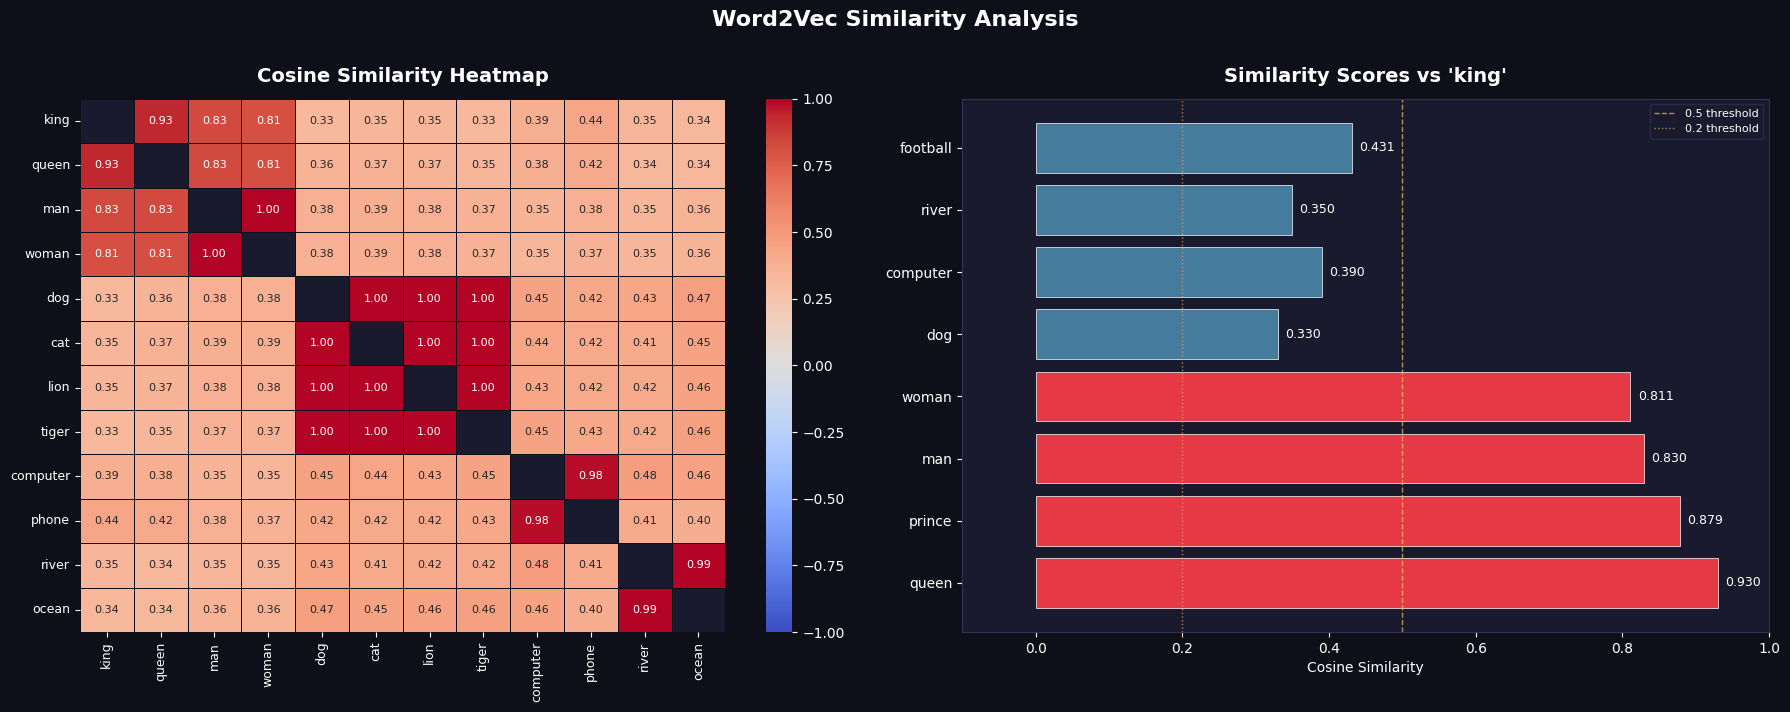


  PAIRWISE SIMILARITY TABLE

  Word 1       Word 2       Similarity
  ------------------------------------
  king         queen            0.9303  █████████████
  dog          cat              0.9972  ██████████████
  computer     phone            0.9815  ██████████████
  river        ocean            0.9942  ██████████████
  king         dog              0.3301  ████
  computer     river            0.4800  ███████


In [1]:
!pip install gensim -q

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity

# Training corpus
corpus = [
    "king queen prince princess royal throne crown kingdom palace noble",
    "man woman boy girl person human child adult",
    "dog cat lion tiger elephant horse bear wolf animal pet",
    "computer laptop phone tablet technology software hardware internet network",
    "doctor nurse hospital medicine surgery patient health clinic",
    "teacher student school university education learning knowledge class",
    "car bus train airplane ship bicycle transport vehicle travel",
    "apple banana mango orange grape strawberry fruit vegetable food",
    "football cricket tennis basketball swimming boxing sport athlete game",
    "river mountain forest ocean desert valley lake island nature",
    "the king rules the kingdom from his royal throne with a crown",
    "the queen and princess live in the palace with the noble prince",
    "a man and woman walked with their boy and girl in the park",
    "the dog and cat are pets while lion and tiger are wild animals",
    "computer software and hardware are connected through the internet network",
    "the doctor and nurse work in the hospital treating patient health",
    "the teacher helps the student learn knowledge at school and university",
    "car and bus are road transport while airplane travels through air",
    "apple mango banana orange are fruits used as food",
    "football cricket tennis are popular sport games played by athletes",
    "river flows through the forest near mountain and valley to ocean",
    "king queen man woman royal human noble person adult child",
    "dog wolf bear cat lion tiger horse elephant animal nature wild",
    "computer phone tablet laptop internet software technology network hardware",
]

tokenized = [sent.lower().split() for sent in corpus]

# Train Word2Vec
model = Word2Vec(tokenized, vector_size=150, window=6,
                 min_count=1, workers=4, epochs=500, sg=1, negative=10)

print("✅ Word2Vec model trained | Vocabulary size:", len(model.wv))

# ── 1. Most Similar Words ─────────────────────────────────────────────────────
query_words = ['king', 'dog', 'computer', 'doctor', 'football', 'river']

print("\n" + "="*60)
print("  TOP SIMILAR WORDS")
print("="*60)
for word in query_words:
    if word in model.wv:
        similar = model.wv.most_similar(word, topn=5)
        print(f"\n🔍 '{word}':")
        for w, score in similar:
            bar = '█' * int(score * 20)
            print(f"   {w:<15} {score:.4f}  {bar}")

# ── 2. Word Analogy (king - man + woman = ?) ─────────────────────────────────
print("\n" + "="*60)
print("  WORD ANALOGIES")
print("="*60)
analogies = [
    ('king',     'man',   'woman'),
    ('doctor',   'hospital', 'school'),
    ('car',      'road',  'air'),
    ('football', 'sport', 'animal'),
]
for pos1, neg1, pos2 in analogies:
    try:
        result = model.wv.most_similar(positive=[pos1, pos2], negative=[neg1], topn=3)
        print(f"\n  {pos1} - {neg1} + {pos2} ≈")
        for w, s in result:
            print(f"    → {w:<15} ({s:.4f})")
    except KeyError as e:
        print(f"  Skipping analogy ({e} not in vocab)")

# ── 3. Odd-One-Out ────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("  ODD ONE OUT")
print("="*60)
groups = [
    ['king', 'queen', 'prince', 'dog'],
    ['computer', 'laptop', 'phone', 'river'],
    ['football', 'cricket', 'tennis', 'doctor'],
    ['apple', 'banana', 'mango', 'car'],
]
for group in groups:
    valid = [w for w in group if w in model.wv]
    if valid:
        odd = model.wv.doesnt_match(valid)
        print(f"  {valid}  →  Odd: '{odd}'")

# ── 4. Cosine Similarity Heatmap ──────────────────────────────────────────────
heatmap_words = ['king', 'queen', 'man', 'woman',
                 'dog',  'cat',   'lion', 'tiger',
                 'computer', 'phone', 'river', 'ocean']
heatmap_words = [w for w in heatmap_words if w in model.wv]

vectors = np.array([model.wv[w] for w in heatmap_words])
sim_matrix = cosine_similarity(vectors)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#0F0F1A')

# Heatmap
ax1 = axes[0]
ax1.set_facecolor('#1A1A2E')
mask = np.eye(len(heatmap_words), dtype=bool)
sns.heatmap(sim_matrix, annot=True, fmt=".2f",
            xticklabels=heatmap_words, yticklabels=heatmap_words,
            cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, linecolor='#0F0F1A',
            ax=ax1, mask=mask, annot_kws={'size': 8})
ax1.set_title("Cosine Similarity Heatmap", fontsize=14,
              fontweight='bold', color='white', pad=12)
ax1.tick_params(colors='white', labelsize=9)
ax1.figure.axes[-1].tick_params(colors='white')

# Bar chart — similarity to 'king'
ax2 = axes[1]
ax2.set_facecolor('#1A1A2E')
compare_word = 'king'
compare_words = ['queen', 'prince', 'man', 'woman', 'dog', 'computer', 'river', 'football']
compare_words = [w for w in compare_words if w in model.wv]
scores = [model.wv.similarity(compare_word, w) for w in compare_words]
bar_colors = ['#E63946' if s > 0.5 else '#457B9D' if s > 0.2 else '#6C757D'
              for s in scores]

bars = ax2.barh(compare_words, scores, color=bar_colors,
                edgecolor='white', linewidth=0.5)
ax2.axvline(x=0.5, color='#E9C46A', linestyle='--', linewidth=1, alpha=0.7, label='0.5 threshold')
ax2.axvline(x=0.2, color='#F4A261', linestyle=':', linewidth=1, alpha=0.7, label='0.2 threshold')

for bar, score in zip(bars, scores):
    ax2.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{score:.3f}', va='center', color='white', fontsize=9)

ax2.set_xlim(-0.1, 1.0)
ax2.set_title(f"Similarity Scores vs '{compare_word}'",
              fontsize=14, fontweight='bold', color='white', pad=12)
ax2.set_xlabel("Cosine Similarity", color='white')
ax2.tick_params(colors='white')
ax2.legend(fontsize=8, facecolor='#1A1A2E', labelcolor='white',
           edgecolor='#444466', framealpha=0.4)
for spine in ax2.spines.values():
    spine.set_edgecolor('#333355')

plt.suptitle("Word2Vec Similarity Analysis", fontsize=16,
             fontweight='bold', color='white', y=1.01)
plt.tight_layout()
plt.savefig('word2vec_similarity.png', dpi=150,
            bbox_inches='tight', facecolor='#0F0F1A')
plt.show()

# ── 5. Pairwise similarity table ──────────────────────────────────────────────
print("\n" + "="*60)
print("  PAIRWISE SIMILARITY TABLE")
print("="*60)
pairs = [('king','queen'), ('dog','cat'), ('computer','phone'),
         ('river','ocean'), ('king','dog'), ('computer','river')]
print(f"\n  {'Word 1':<12} {'Word 2':<12} {'Similarity':>10}")
print("  " + "-"*36)
for w1, w2 in pairs:
    if w1 in model.wv and w2 in model.wv:
        sim = model.wv.similarity(w1, w2)
        bar = '█' * int(sim * 15)
        print(f"  {w1:<12} {w2:<12} {sim:>10.4f}  {bar}")